In [1]:
# python
import sys
import os
import importlib
import copy
from pathlib import Path

# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak

# local
sidm_path = str(Path.cwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities, sidm_processor, scaleout, cutflow, histogram as sidm_histogram
from sidm.tools import llpnanoaodschema
from sidm.definitions import hists as sidm_hists

# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
importlib.reload(sidm_hists)

# plotting
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
import coffea.util
import hist
import yaml
from matplotlib.colors import LogNorm

utilities.set_plot_style()
%matplotlib inline

In [2]:
def _dsa_pf_all_pair_dR(objs, mask):
    return utilities.dR_general(objs['dsaMuons'][:, :, None], objs['muons'][:, None, :])


def _dsa_pf_closest_dR(objs, mask):
    return utilities.dR(objs['dsaMuons'], objs['muons'])


def _dsa_pf_nearest_muon(objs, threshold=0.1):
    return objs['dsaMuons'].nearest(objs['muons'], threshold=threshold)


def _nearest_pf_pt_and_match_mask(objs, threshold=0.1):
    nearest_pf = _dsa_pf_nearest_muon(objs, threshold=threshold)
    nearest_pf_pt = ak.fill_none(nearest_pf.pt, np.nan)
    matched = np.isfinite(nearest_pf_pt)
    return nearest_pf_pt, matched


def _dsa_pf_pt_diff_threshold_0p1(objs, mask):
    nearest_pf_pt, matched = _nearest_pf_pt_and_match_mask(objs, threshold=0.1)
    return objs['dsaMuons'].pt[matched] - nearest_pf_pt[matched]


def _dsa_pf_abs_pt_diff_threshold_0p1(objs, mask):
    return abs(_dsa_pf_pt_diff_threshold_0p1(objs, mask))


def _dsa_pf_pt_ratio_threshold_0p1(objs, mask):
    nearest_pf_pt, matched = _nearest_pf_pt_and_match_mask(objs, threshold=0.1)
    return objs['dsaMuons'].pt[matched] / nearest_pf_pt[matched]


def _pf_pt_dsa_pt_threshold_0p1(objs, mask):
    nearest_pf_pt, matched = _nearest_pf_pt_and_match_mask(objs, threshold=0.1)
    return nearest_pf_pt[matched]


def _dsa_pt_pf_pt_threshold_0p1(objs, mask):
    nearest_pf_pt, matched = _nearest_pf_pt_and_match_mask(objs, threshold=0.1)
    return objs['dsaMuons'].pt[matched]


extra_reco_hists = {
    'dsaMu_pfMu_dR_allPairs': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(200, 0, 1, name='dsaMu_pfMu_dR_allPairs', label=r'All-pair Delta R(DSA, PF)'),
            _dsa_pf_all_pair_dR,
        ),
    ]),
    'dsaMu_pfMu_dR_closest': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(200, 0, 1, name='dsaMu_pfMu_dR_closest', label=r'Closest Delta R(DSA, PF)'),
            _dsa_pf_closest_dR,
        ),
    ]),
    'dsaMu_pfMu_pt_diff': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(100, -100, 100, name='dsaMu_pfMu_pt_diff', label=r'pT(DSA) - pT(PF) [GeV], Delta R < 0.1'),
            _dsa_pf_pt_diff_threshold_0p1,
        ),
    ]),
    'dsaMu_pfMu_abs_pt_diff': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(100, 0, 100, name='dsaMu_pfMu_abs_pt_diff', label=r'|pT(DSA) - pT(PF)| [GeV], Delta R < 0.1'),
            _dsa_pf_abs_pt_diff_threshold_0p1,
        ),
    ]),
    'dsaMu_pfMu_pt_ratio': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(100, 0, 5, name='dsaMu_pfMu_pt_ratio', label=r'pT(DSA) / pT(PF), Delta R < 0.1'),
            _dsa_pf_pt_ratio_threshold_0p1,
        ),
    ]),
    'pfMu_pt_dsaMu_pt': sidm_histogram.Histogram([
        sidm_histogram.Axis(
            hist.axis.Regular(100, 0, 200, name='pfMu_pt', label=r'Nearest PF pT [GeV], Delta R < 0.1'),
            _pf_pt_dsa_pt_threshold_0p1,
        ),
        sidm_histogram.Axis(
            hist.axis.Regular(100, 0, 200, name='dsaMu_pt', label=r'DSA pT [GeV], Delta R < 0.1'),
            _dsa_pt_pf_pt_threshold_0p1,
        ),
    ]),
}

sidm_hists.hist_defs.update(extra_reco_hists)
sidm_processor.hist_defs.update(extra_reco_hists)
print('Registered notebook-local histograms:')
for name in extra_reco_hists:
    print('  -', name)


Registered notebook-local histograms:
  - dsaMu_pfMu_dR_allPairs
  - dsaMu_pfMu_dR_closest
  - dsaMu_pfMu_pt_diff
  - dsaMu_pfMu_abs_pt_diff
  - dsaMu_pfMu_pt_ratio
  - pfMu_pt_dsaMu_pt


In [3]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    chunksize=100000,
    skipbadfiles=False,
)

sample_data = 'DoubleMuon_2018A_0'
max_files = 10

cr_channels = [
    'data_control_region_1muLj_cosmic_veto_noCC',
    'data_control_region_1muLj_cosmic_veto_finalCC_segmentFractionLt1',
]

cr_channel_labels = {
    'data_control_region_1muLj_cosmic_veto_noCC': '1MuLJ CV CR, no CC',
    'data_control_region_1muLj_cosmic_veto_finalCC_segmentFractionLt1': '1MuLJ CV CR, final CC + segment fraction < 1',
}

cr_channel_colors = {
    'data_control_region_1muLj_cosmic_veto_noCC': 'tab:red',
    'data_control_region_1muLj_cosmic_veto_finalCC_segmentFractionLt1': 'tab:blue',
}

base_hist_cfg_path = Path('../../configs/hist_collections.yaml') if Path.cwd().name == 'Cross-cleaning_Validation' else Path('configs/hist_collections.yaml')
if not base_hist_cfg_path.exists():
    base_hist_cfg_path = Path('configs/hist_collections.yaml')

base_selection_cfg_path = Path('../../configs/selections.yaml') if Path.cwd().name == 'Cross-cleaning_Validation' else Path('configs/selections.yaml')
if not base_selection_cfg_path.exists():
    base_selection_cfg_path = Path('configs/selections.yaml')

with open(base_hist_cfg_path, 'r') as f:
    hist_menu = yaml.safe_load(f)

with open(base_selection_cfg_path, 'r') as f:
    selection_menu = yaml.safe_load(f)


def _map_nested_cuts(cuts, transform):
    if isinstance(cuts, list):
        mapped = []
        for cut in cuts:
            item = _map_nested_cuts(cut, transform)
            if item is None:
                continue
            if isinstance(item, list) and len(item) == 0:
                continue
            mapped.append(item)
        return mapped
    return transform(cuts)


def _make_1mulj_cr_channel(source_channel, cc_mode):
    cfg = copy.deepcopy(selection_menu[source_channel])
    dsa_cuts = cfg['obj_cuts'].get('dsaMuons', [])

    def transform(cut):
        if cut == 'all':
            if cc_mode == 'noCC':
                return None
            if cc_mode == 'finalCC_segmentFractionLt1':
                return 'all + segment fraction < 1'
        return cut

    cfg['obj_cuts']['dsaMuons'] = _map_nested_cuts(dsa_cuts, transform)
    return cfg


selection_menu['data_control_region_1muLj_cosmic_veto_noCC'] = _make_1mulj_cr_channel(
    'data_control_region_1muLj_cosmic_veto',
    cc_mode='noCC',
)
selection_menu['data_control_region_1muLj_cosmic_veto_finalCC_segmentFractionLt1'] = _make_1mulj_cr_channel(
    'data_control_region_1muLj_cosmic_veto',
    cc_mode='finalCC_segmentFractionLt1',
)
tmp_selection_cfg_path = Path('data_cc_validation_selections.tmp.yaml')
with open(tmp_selection_cfg_path, 'w') as f:
    yaml.safe_dump(selection_menu, f, sort_keys=False)

data_reco_cc_hists = [
    'pf_dsa_cc_dR_outer',
    'pf_dsa_cc_dR_outer_numMatchGe1',
    'pf_dsa_cc_numMatch',
    'pf_dsa_cc_numMatch_allPairs',
    'pf_dsa_cc_numMatch_numMatchGe1',
    'pf_dsa_cc_numMatch_perDsaWithNoMatchZero',
    'pf_dsa_cc_nSegments',
    'pf_dsa_cc_nSegments_numMatchGe1',
    'pf_dsa_cc_segment_fraction',
    'pf_dsa_cc_segment_fraction_numMatchGe1',
    'pf_dsa_cc_cut_plane',
    'pf_dsa_cc_cut_plane_numMatchGe1',
]

hist_menu['data_cc_validation_base'] = data_reco_cc_hists + list(extra_reco_hists)

tmp_hist_cfg_path = Path('data_cc_validation_hist_collections.tmp.yaml')
with open(tmp_hist_cfg_path, 'w') as f:
    yaml.safe_dump(hist_menu, f, sort_keys=False)

fileset = utilities.make_fileset(
    [sample_data],
    'llpNanoAOD_v2',
    location_cfg='data_skimmed.yaml',
    max_files=max_files,
)


def run_validation_channels(channels_to_run, output_path):
    p = sidm_processor.SidmProcessor(
        channels_to_run,
        ['data_cc_validation_base'],
        selections_cfg=str(tmp_selection_cfg_path),
        histograms_cfg=str(tmp_hist_cfg_path),
        unweighted_hist=True,
        verbose=True,
    )
    print(f'Processing {sample_data} with {max_files} files')
    output = runner.run(fileset, treename='Events', processor_instance=p)
    coffea.util.save(output, output_path)
    print(f'Saved {output_path}')
    return output, output['out']


In [4]:
output_data_cr, out_data_cr = run_validation_channels(
    cr_channels,
    f'data_cc_validation_1muLjCV_{max_files}files.coffea',
)

Output()

Processing DoubleMuon_2018A_0 with 10 files


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel 
object at 0x7fed450bbb00>>

Traceback (most recent call last):

File "/usr/local/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames

...

Warning: genAs not found in this sample. Skipping.

Warning: genAs_toMu not found in this sample. Skipping.

Warning: genAs_toE not found in this sample. Skipping.

Warning: fs_gens not found in this sample. Skipping.

Exception: Failed processing file: WorkItem(dataset='DoubleMuon_2018A_0', filename='root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018A_15Feb2022_UL2018/0000/skimmed_output_107.root', treename='Events', entrystart=0, entrystop=1438, fileuuid=b'\x0b\xdb\x81\xf8\x01K\x11\xf1\x81\xf2\xf9\xbe\xe1\x83\xbe\xef', usermeta={'skim_factor': 0.3395500686047371, 'year': '2018', 'is_data': True})

In [ ]:
def get_hist_store(out, sample):
    if sample not in out:
        raise KeyError(f'Sample {sample!r} not found. Available: {list(out.keys())}')
    sample_output = out[sample]
    if 'hists' in sample_output:
        return sample_output['hists']
    return sample_output


def get_histogram(out, sample, histname):
    hist_store = get_hist_store(out, sample)
    if histname not in hist_store:
        raise KeyError(f'Histogram {histname!r} was not found. Available examples: {list(hist_store)[:20]}')
    return hist_store[histname]


def slice_histogram_channel(histogram, channel):
    axis_names = [axis.name for axis in histogram.axes]
    if 'channel' in axis_names:
        return histogram[{'channel': channel}]
    raise KeyError(f'No channel axis found. Axes: {axis_names}')


def reduce_to_1d(histogram):
    h = histogram
    while len(h.axes) > 1:
        reduced = False
        for axis in h.axes:
            try:
                categories = list(axis)
            except Exception:
                categories = []
            if categories:
                h = h[{axis.name: sum}]
                reduced = True
                break
        if not reduced:
            raise ValueError(f'Cannot reduce numeric histogram to 1D. Axes: {[axis.name for axis in h.axes]}')
    return h


def reduce_to_2d(histogram):
    h = histogram
    while len(h.axes) > 2:
        reduced = False
        for axis in h.axes:
            try:
                categories = list(axis)
            except Exception:
                categories = []
            if categories:
                h = h[{axis.name: sum}]
                reduced = True
                break
        if not reduced:
            raise ValueError(f'Cannot reduce numeric histogram to 2D. Axes: {[axis.name for axis in h.axes]}')
    if len(h.axes) != 2:
        raise ValueError(f'Expected 2D histogram, found {len(h.axes)} axes')
    return h


def histogram_errors(histogram):
    values = np.asarray(histogram.values(), dtype=float)
    variances = histogram.variances()
    if variances is None:
        return np.sqrt(np.abs(values))
    variances = np.asarray(variances, dtype=float)
    variances = np.where(np.isfinite(variances) & (variances >= 0), variances, 0.0)
    return np.sqrt(variances)


def extract_1d(out, sample, histname, channel):
    h = get_histogram(out, sample, histname)
    h = reduce_to_1d(slice_histogram_channel(h, channel))
    values = np.asarray(h.values(), dtype=float)
    errors = histogram_errors(h)
    edges = np.asarray(h.axes[0].edges, dtype=float)
    return values, errors, edges


def extract_2d(out, sample, histname, channel):
    h = get_histogram(out, sample, histname)
    h = reduce_to_2d(slice_histogram_channel(h, channel))
    values = np.asarray(h.values(), dtype=float)
    x_edges = np.asarray(h.axes[0].edges, dtype=float)
    y_edges = np.asarray(h.axes[1].edges, dtype=float)
    return values, x_edges, y_edges


def bin_centers(edges):
    return 0.5 * (edges[:-1] + edges[1:])


def normalize_values(values, errors):
    total = np.sum(values)
    if total <= 0:
        return values * np.nan, errors * np.nan
    return values / total, errors / total

In [6]:
def plot_channel_overlay_1d(
    out,
    sample,
    histname,
    plot_channels,
    labels,
    colors,
    xlabel=None,
    normalize=False,
    logy=False,
    xlim=None,
    ylim=None,
    vertical_lines=None,
    figsize=(14, 10),
):
    fig, ax = plt.subplots(figsize=figsize)

    for channel in plot_channels:
        values, errors, edges = extract_1d(out, sample, histname, channel)
        if normalize:
            values, errors = normalize_values(values, errors)

        centers = bin_centers(edges)
        label = labels.get(channel, channel)
        color = colors.get(channel)

        ax.stairs(values, edges, label=label, color=color, linewidth=2.5)
        ax.errorbar(
            centers,
            values,
            yerr=errors,
            fmt='o',
            markersize=3,
            color=color,
            ecolor=color,
            elinewidth=1,
            capsize=1,
            alpha=0.8,
        )

    if vertical_lines is not None:
        for x in vertical_lines:
            ax.axvline(x, color='gray', linestyle='--', linewidth=1.5)

    if logy:
        ax.set_yscale('log')
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xlabel(xlabel if xlabel is not None else histname)
    ax.set_ylabel('Normalized entries' if normalize else 'Entries')
    ax.set_title(f'{sample}: {histname}')
    ax.grid(True, which='both', linestyle=':', alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_pf_dsa_pt_2d(out, sample, plot_channels, labels, histname='pfMu_pt_dsaMu_pt', figsize=None):
    if figsize is None:
        figsize = (12 * len(plot_channels), 10)
    fig, axes = plt.subplots(1, len(plot_channels), figsize=figsize, sharex=True, sharey=True)
    if len(plot_channels) == 1:
        axes = [axes]

    for ax, channel in zip(axes, plot_channels):
        values, x_edges, y_edges = extract_2d(out, sample, histname, channel)
        positive = values[values > 0]
        norm = LogNorm(vmin=positive.min(), vmax=positive.max()) if positive.size else None

        mesh = ax.pcolormesh(
            x_edges,
            y_edges,
            values.T,
            shading='auto',
            norm=norm,
        )
        ax.plot([0, 200], [0, 200], color='red', linestyle='--', linewidth=1.5, label='DSA pT = PF pT')
        ax.set_title(labels.get(channel, channel))
        ax.set_xlabel(r'Nearest PF pT [GeV], Delta R < 0.1')
        ax.legend(frameon=False, loc='upper left')
        fig.colorbar(mesh, ax=ax, label='Entries')

    axes[0].set_ylabel(r'DSA pT [GeV]')
    fig.suptitle(f'{sample}: PF pT vs DSA pT')
    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_cut_plane(out, sample, plot_channels, labels, histname='pf_dsa_cc_cut_plane_numMatchGe1', figsize=None):
    dR_cut = 0.1
    segment_fraction_cut = 0.34

    if figsize is None:
        figsize = (12 * len(plot_channels), 10)
    fig, axes = plt.subplots(1, len(plot_channels), figsize=figsize, sharex=True, sharey=True)
    if len(plot_channels) == 1:
        axes = [axes]

    for ax, channel in zip(axes, plot_channels):
        values, x_edges, y_edges = extract_2d(out, sample, histname, channel)
        positive = values[values > 0]
        norm = LogNorm(vmin=positive.min(), vmax=positive.max()) if positive.size else None

        mesh = ax.pcolormesh(
            x_edges,
            y_edges,
            values.T,
            shading='auto',
            norm=norm,
        )
        ax.axvline(dR_cut, linestyle='--', linewidth=2, color='red', label=f'Delta R_outer = {dR_cut}')
        ax.axhline(segment_fraction_cut, linestyle='--', linewidth=2, color='red', label=f'Segment fraction = {segment_fraction_cut}')
        ax.axhline(1.0, linestyle=':', linewidth=2, color='black', label='Segment fraction = 1')
        ax.set_title(labels.get(channel, channel))
        ax.set_xlabel(r'Delta R_outer(DSA, PF)')
        ax.legend(frameon=False, loc='center right')
        fig.colorbar(mesh, ax=ax, label='Entries')

    axes[0].set_ylabel('Shared segment fraction')
    fig.suptitle(f'{sample}: PF-DSA cross-cleaning cut plane (numMatch >= 1)')
    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_validation_suite(out, sample, plot_channels, labels, colors, title_prefix):
    reco_1d_plots = [
        ('dsaMu_pfMu_dR_allPairs', r'All-pair Delta R(DSA, PF)', (0, 1), [0.1]),
        ('dsaMu_pfMu_dR_closest', r'Closest Delta R(DSA, PF)', (0, 1), [0.1]),
        ('dsaMu_pfMu_pt_diff', r'pT(DSA) - pT(PF) [GeV], nearest PF with Delta R < 0.1', (-100, 100), [0]),
        ('dsaMu_pfMu_abs_pt_diff', r'|pT(DSA) - pT(PF)| [GeV], nearest PF with Delta R < 0.1', (0, 100), None),
        ('dsaMu_pfMu_pt_ratio', r'pT(DSA) / pT(PF), nearest PF with Delta R < 0.1', (0, 5), [1]),
    ]

    smoke_reco_hists = [
        ('pf_dsa_cc_dR_outer_numMatchGe1', r'PF--DSA outer Delta R (numMatch >= 1)', (0, 1), [0.1]),
        ('pf_dsa_cc_numMatch_numMatchGe1', 'Number of PF--DSA matched segments (numMatch >= 1)', None, None),
        ('pf_dsa_cc_nSegments_numMatchGe1', 'Number of DSA segments (numMatch >= 1)', (0, 10), None),
        ('pf_dsa_cc_segment_fraction_numMatchGe1', 'PF--DSA matched segment fraction (numMatch >= 1)', (0, 1.2), [0.34, 1.0]),
    ]

    print(title_prefix)
    print('1D reco PF-DSA overlays')
    for histname, xlabel, xlim, vertical_lines in reco_1d_plots:
        plot_channel_overlay_1d(
            out,
            sample,
            histname,
            plot_channels,
            labels,
            colors,
            xlabel=xlabel,
            normalize=False,
            logy=False,
            xlim=xlim,
            vertical_lines=vertical_lines,
        )

    for histname, xlabel, xlim, vertical_lines in reco_1d_plots:
        plot_channel_overlay_1d(
            out,
            sample,
            histname,
            plot_channels,
            labels,
            colors,
            xlabel=xlabel,
            normalize=True,
            logy=False,
            xlim=xlim,
            vertical_lines=vertical_lines,
        )

    print('PF pT vs DSA pT')
    plot_pf_dsa_pt_2d(out, sample, plot_channels, labels)

    print('Existing CC smoke-test reco plots')
    for histname, xlabel, xlim, vertical_lines in smoke_reco_hists:
        plot_channel_overlay_1d(
            out,
            sample,
            histname,
            plot_channels,
            labels,
            colors,
            xlabel=xlabel,
            normalize=False,
            logy=False,
            xlim=xlim,
            vertical_lines=vertical_lines,
        )

    for histname, xlabel, xlim, vertical_lines in smoke_reco_hists:
        plot_channel_overlay_1d(
            out,
            sample,
            histname,
            plot_channels,
            labels,
            colors,
            xlabel=xlabel,
            normalize=True,
            logy=False,
            xlim=xlim,
            vertical_lines=vertical_lines,
        )

    print('PF-DSA cut plane')
    plot_cut_plane(out, sample, plot_channels, labels)


def print_cutflows(out, sample, plot_channels, labels):
    for channel in plot_channels:
        print()
        print(labels.get(channel, channel))
        out[sample]['cutflow'][channel].print_table()


## 1MuLJ CV CR Plots

1MuLJ cosmic-veto control region
1D reco PF-DSA overlays


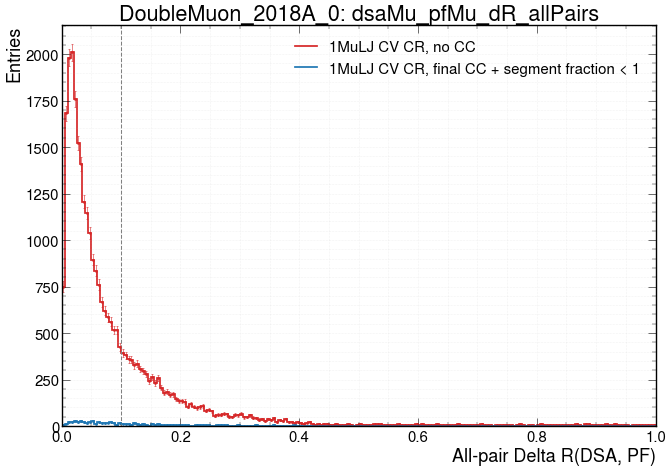

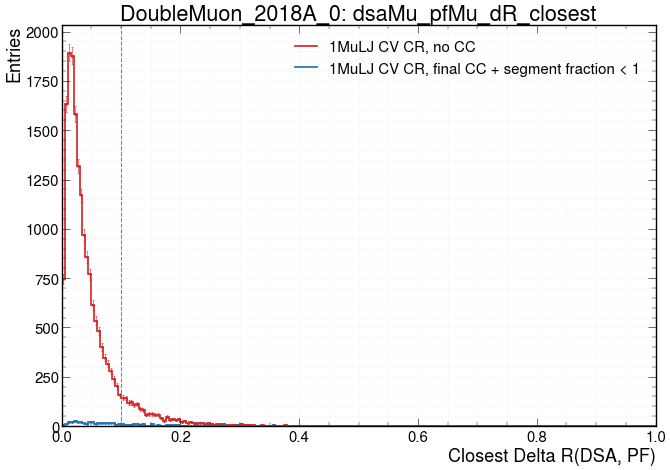

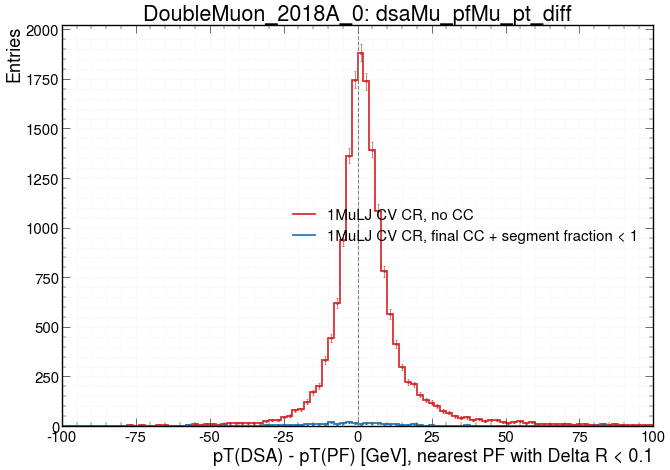

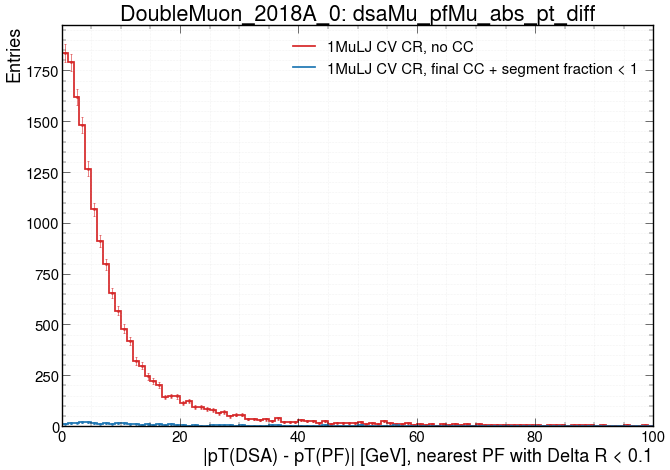

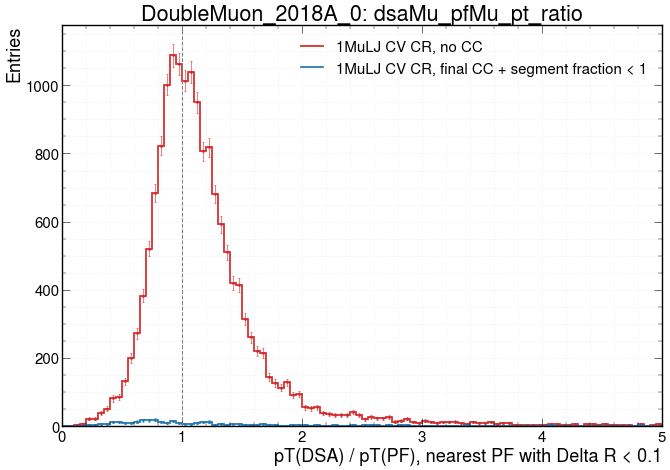

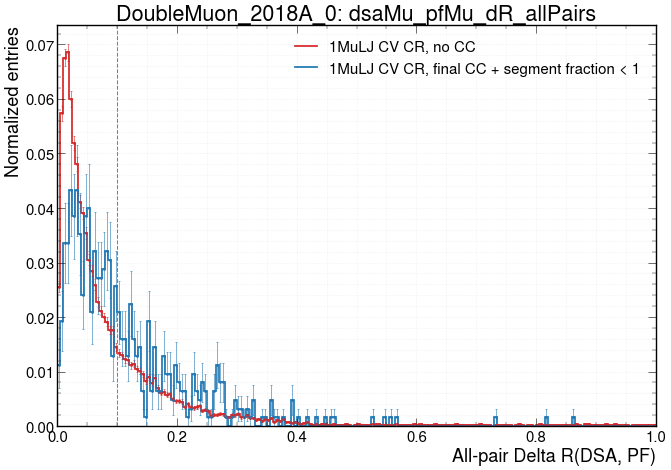

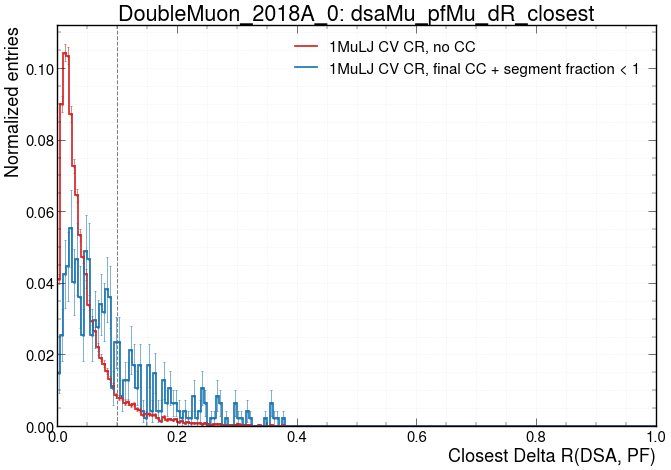

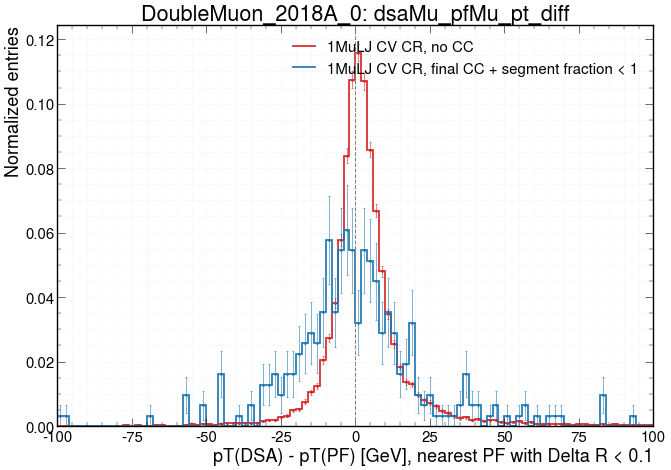

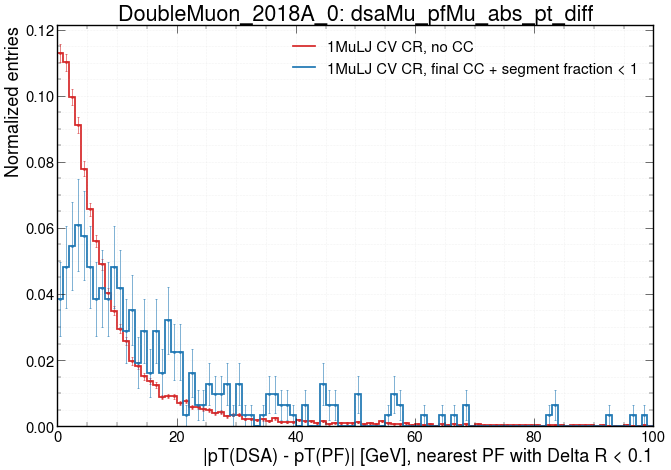

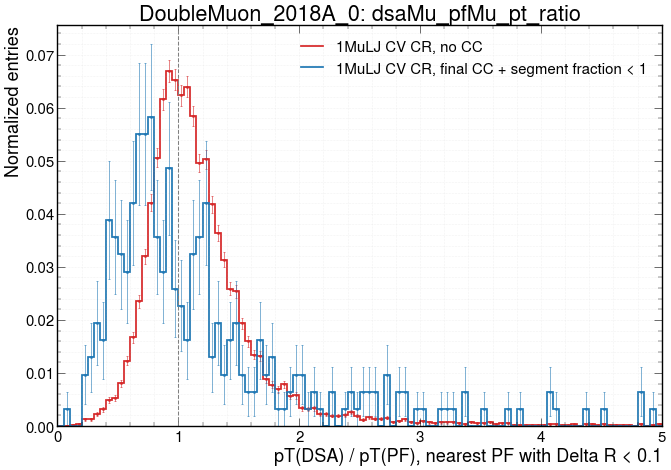

PF pT vs DSA pT


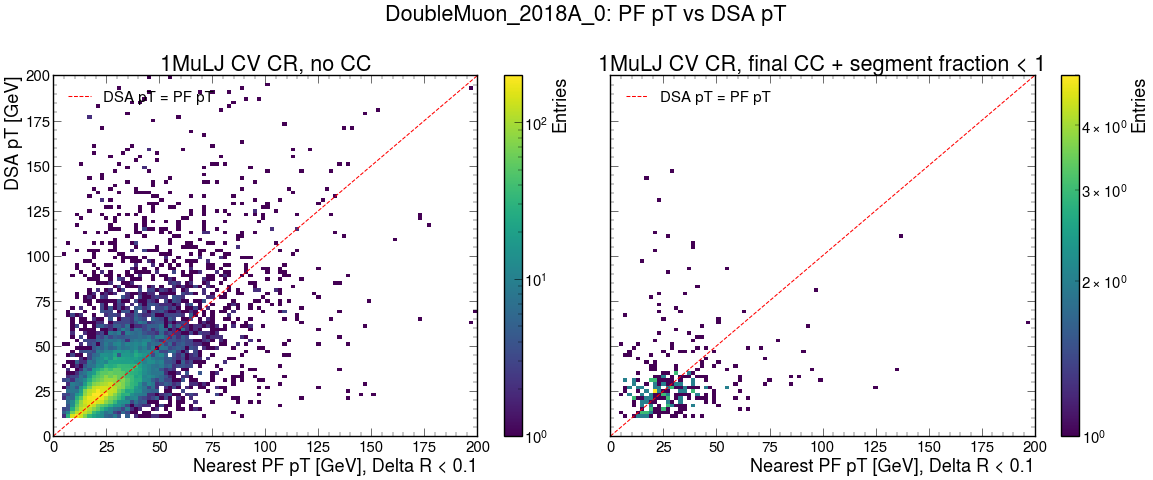

Existing CC smoke-test reco plots


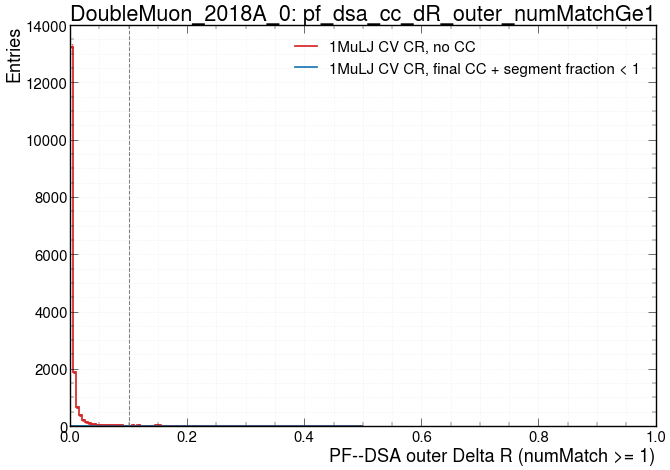

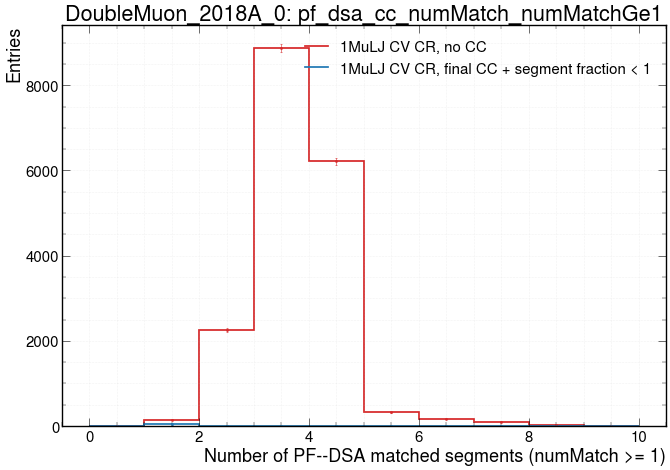

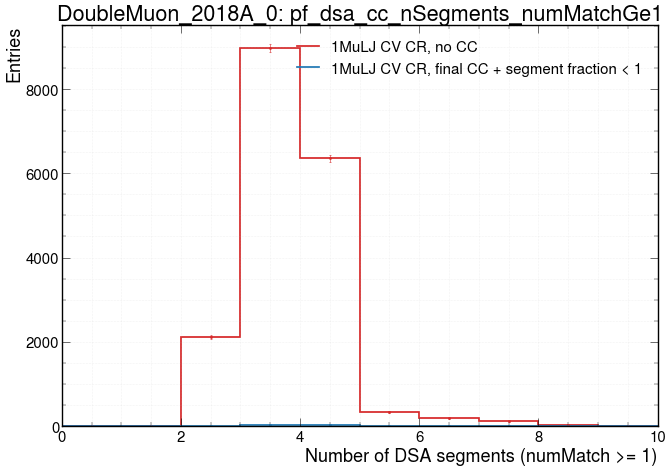

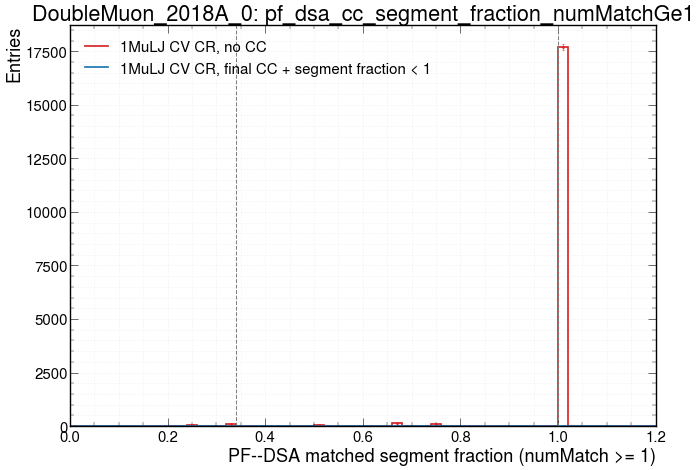

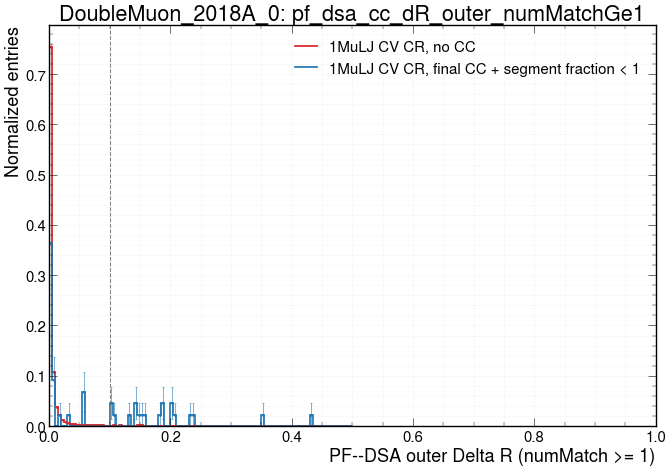

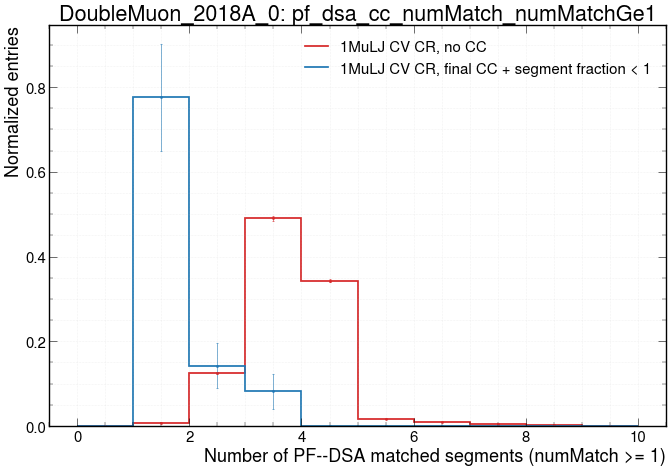

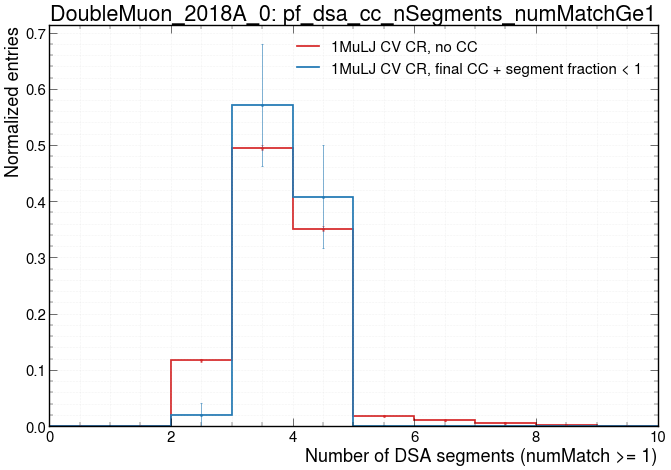

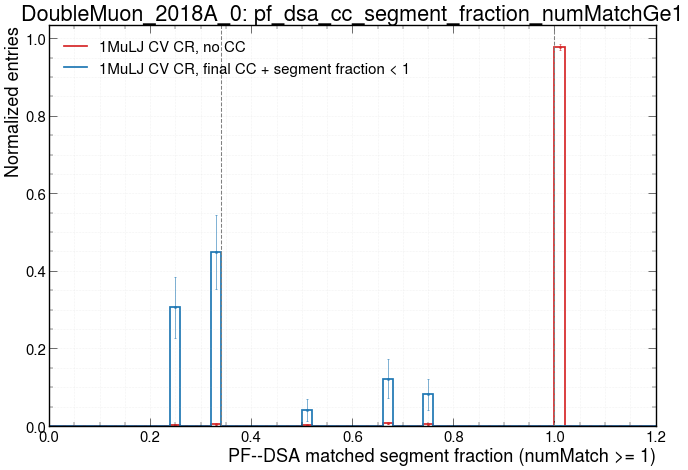

PF-DSA cut plane


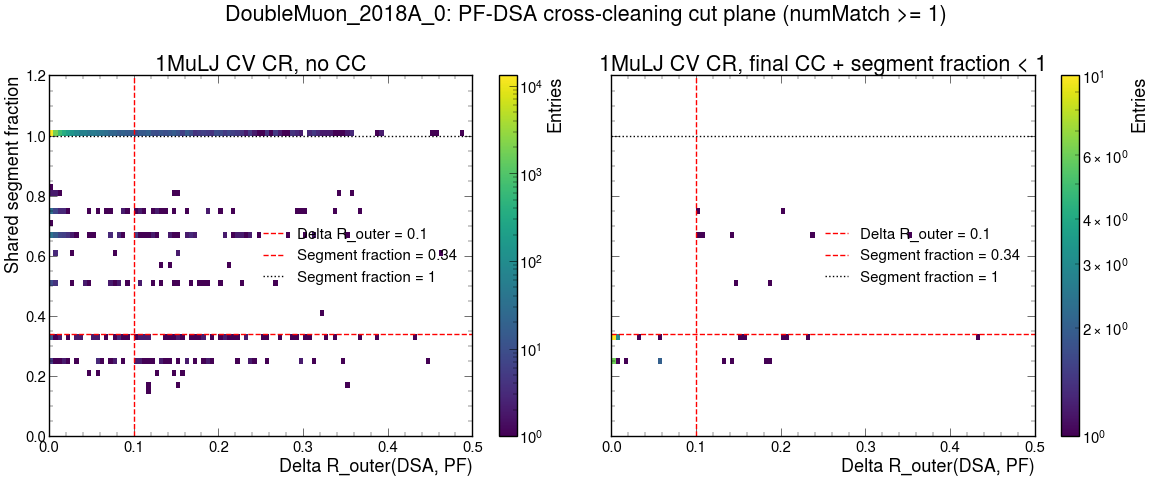


1MuLJ CV CR, no CC
cut name                          raw N    weighted N    weighted %
------------------------------  -------  ------------  ------------
None                            86525.0       86525.0         100.0
pass triggers                   58247.0       58247.0          67.3
PV filter                       58188.0       58188.0          67.2
pass flags                      58104.0       58104.0          67.2
= 1 LJs                         15308.0       15308.0          17.7
= 1 muLJs                       14489.0       14489.0          16.7
all cos_alpha(dsa, dsa) > -0.9  14371.0       14371.0          16.6

1MuLJ CV CR, final CC + segment fraction < 1
cut name                          raw N    weighted N    weighted %
------------------------------  -------  ------------  ------------
None                            86525.0       86525.0         100.0
pass triggers                   58247.0       58247.0          67.3
PV filter                       58188.0       5818

In [7]:
plot_validation_suite(
    out_data_cr,
    sample_data,
    cr_channels,
    cr_channel_labels,
    cr_channel_colors,
    title_prefix='1MuLJ cosmic-veto control region',
)

print_cutflows(out_data_cr, sample_data, cr_channels, cr_channel_labels)
